<a href="https://colab.research.google.com/github/Amirthagenius/Multi-Layered-Behavioral-Fraud-Detection/blob/main/01_generate_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ==========================================================
# 📦 DATASET GENERATION NOTEBOOK (ORGANIZER ONLY)
# ==========================================================
# ⚠️ IMPORTANT:
# Students DO NOT need to run this notebook.
# Dataset is already generated and available in /data folder.
# This notebook is for reference only.

# ==========================================================
# 🎯 PURPOSE OF THIS DATASET
# ==========================================================
# This dataset simulates customer behavior and transactions.
# It supports multiple machine learning problems such as:
# - Customer churn prediction
# - Fraud detection
# - Revenue prediction

In [2]:
# ==========================================================
# 📚 LIBRARIES
# ==========================================================
import pandas as pd
import numpy as np

In [3]:
# Fix randomness for reproducibility
np.random.seed(42)

In [4]:
# ==========================================================
# 🔢 STEP 1 — CREATE BASE DATA
# ==========================================================
# Number of records
n = 5000

df = pd.DataFrame({
    "customer_id": range(1, n+1),  # Unique ID
    "age": np.random.randint(18, 70, n),  # Customer age
    "gender": np.random.choice(["Male", "Female"], n),
    "country": np.random.choice(["UK", "US", "India", "Germany"], n),
    "tenure_months": np.random.randint(1, 60, n),  # Customer duration
    "monthly_spend": np.random.uniform(20, 500, n),  # Monthly spending
    "num_transactions": np.random.randint(1, 100, n),  # Activity level
    "last_login_days": np.random.randint(1, 30, n),  # Engagement
    "support_tickets": np.random.randint(0, 10, n),
    "payment_method": np.random.choice(["Card", "PayPal", "Crypto"], n),
    "is_active": np.random.choice([0, 1], n)
})

In [5]:
# ==========================================================
# 🔧 STEP 2 — FEATURE ENGINEERING (PRE-BUILT)
# ==========================================================
# These are example features students can use or improve

df["total_spend"] = df["monthly_spend"] * df["tenure_months"]
df["avg_transaction_value"] = df["total_spend"] / (df["num_transactions"] + 1)

In [6]:
# ==========================================================
# 🎯 STEP 3 — TARGET VARIABLES (MULTI-PROBLEM SUPPORT)
# ==========================================================
# 👉 Students will choose ONE target depending on their task

df["target_churn"] = (
    (df["last_login_days"] > 15).astype(int) * 0.4 +
    (df["num_transactions"] < 5).astype(int) * 0.3 +
    (df["total_spend"] < 500).astype(int) * 0.3 +
    np.random.rand(n) * 0.3
) > 0.7

df["target_churn"] = df["target_churn"].astype(int)

# Revenue Prediction (Regression)
df["target_revenue"] = (
    df["monthly_spend"] *
    (0.7 + 0.6 * np.random.rand(n)) +
    df["num_transactions"] * 2 +
    np.random.normal(0, 50, n)
)

# Fraud Detection (Classification)
df["target_fraud"] = (
    (df["num_transactions"] > 70).astype(int) * 0.5 +
    (df["avg_transaction_value"] > 200).astype(int) * 0.3 +
    (df["last_login_days"] < 2).astype(int) * 0.2 +
    np.random.rand(n) * 0.3
) > 0.75

df["target_fraud"] = df["target_fraud"].astype(int)

In [7]:
# Add 10% noise to all classification targets
for col in ["target_churn", "target_fraud"]:
    noise_mask = np.random.rand(n) < 0.1
    df.loc[noise_mask, col] = 1 - df.loc[noise_mask, col]

In [8]:
# ==========================================================
# ✂️ STEP 4 — TRAIN / TEST SPLIT
# ==========================================================
# 80% training, 20% testing

train = df.sample(frac=0.8, random_state=42)
test = df.drop(train.index)

In [9]:
# ============================================================
# 💾 STEP 5 — SAVE DATA (Google Drive version)
# ============================================================
# !rom google.colab import drive
# drive.mount('/content/drive')

import os

# Create the folder if it doesn't exist
BASE = ''
os.makedirs(BASE + 'data', exist_ok=True)

# Save files
train.to_csv(BASE + 'data/train.csv', index=False)
test.to_csv(BASE + 'data/test.csv', index=False)

In [10]:
# ==========================================================
# ✅ SUCCESS MESSAGE
# ==========================================================
print("✅ Dataset created successfully!")
print(f"Train Shape: {train.shape}")
print(f"Test Shape: {test.shape}")

✅ Dataset created successfully!
Train Shape: (4000, 16)
Test Shape: (1000, 16)


In [11]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
# Loading train and test data

train = pd.read_csv(BASE + 'data/train.csv')
test  = pd.read_csv(BASE + 'data/test.csv')

print(f"Train shape: {train.shape}")
print(f"Test  shape: {test.shape}")

# I work only on train- i did't touch test data
df = train.copy()
print(f"\nWorking dataframe shape: {df.shape}")

Train shape: (4000, 16)
Test  shape: (1000, 16)

Working dataframe shape: (4000, 16)


In [13]:
print(" FIRST 5 ROWS")
display(df.head())

print("LAST 5 ROWS")
display(df.tail())

print("COLUMN NAMES")
print(df.columns.tolist())

 FIRST 5 ROWS


,customer_id,age,gender,country,tenure_months,monthly_spend,num_transactions,last_login_days,support_tickets,payment_method,is_active,total_spend,avg_transaction_value,target_churn,target_revenue,target_fraud
0,1502,59,Male,Germany,2,185.360890,52,18,5,PayPal,0,370.721781,6.994751,1,382.034265,0
1,2587,25,Female,US,54,108.879222,35,17,7,Card,1,5879.477977,163.318833,0,217.996705,1
2,2654,38,Female,Germany,48,221.927474,5,2,5,PayPal,1,10652.518741,1775.419790,0,208.955628,0
3,1056,48,Male,US,26,275.346433,14,26,5,Card,1,7159.007247,477.267150,0,248.913546,0
4,706,53,Male,UK,15,444.016783,95,20,0,Card,1,6660.251746,69.377622,0,768.714022,0


LAST 5 ROWS


,customer_id,age,gender,country,tenure_months,monthly_spend,num_transactions,last_login_days,support_tickets,payment_method,is_active,total_spend,avg_transaction_value,target_churn,target_revenue,target_fraud
3995,3336,55,Female,UK,3,171.334646,2,16,9,Crypto,1,514.003939,171.334646,1,167.517091,0
3996,1921,53,Male,UK,40,60.644555,32,14,5,PayPal,1,2425.782181,73.508551,0,208.407232,0
3997,3716,43,Female,UK,17,257.557570,41,17,2,Crypto,0,4378.478695,104.249493,0,326.715811,0
3998,4647,68,Female,UK,31,169.479562,4,14,2,Crypto,1,5253.866418,1050.773284,1,196.703293,0
3999,947,38,Male,India,53,40.535969,39,22,3,PayPal,1,2148.406344,53.710159,0,144.333669,0


COLUMN NAMES
['customer_id', 'age', 'gender', 'country', 'tenure_months', 'monthly_spend', 'num_transactions', 'last_login_days', 'support_tickets', 'payment_method', 'is_active', 'total_spend', 'avg_transaction_value', 'target_churn', 'target_revenue', 'target_fraud']


# Test data

In [14]:
 # Working on train and test
df = train.copy()

test_df = test.copy()

# Check missing values in test
print("\n MISSING VALUES IN TEST")
missing = test_df.isnull().sum()
if missing.sum() == 0:
    print("No missing values found! Test data is clean.")
else:
    print(missing[missing > 0])

# Check test columns match train
print(f"\n COLUMN MATCH")
print(f"Train columns: {df.shape[1]}")
print(f"Test columns: {test_df.shape[1]}")
print(f"Columns match: {list(df.columns) == list(test_df.columns)}")


test_df.to_csv(BASE + 'data/test_clean.csv', index=False)

print(f"Shape: {test_df.shape}")


verify = pd.read_csv(BASE + 'data/test_clean.csv')
print(f"\nVerification — reloaded shape: {verify.shape}")
print(f"Missing values: {verify.isnull().sum().sum()}")


 MISSING VALUES IN TEST
No missing values found! Test data is clean.

 COLUMN MATCH
Train columns: 16
Test columns: 16
Columns match: True
Shape: (1000, 16)

Verification — reloaded shape: (1000, 16)
Missing values: 0


# Train.csv

In [15]:
# Checking missing values

missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct.round(2)})

print("MISSING VALUES")
print(missing_df)

if missing.sum() == 0:
    print("\n No missing values found! Data is clean.")
else:
    print(f"\n Found missing values — needs handling!")

MISSING VALUES
                       Missing Count  Missing %
customer_id                        0        0.0
age                                0        0.0
gender                             0        0.0
country                            0        0.0
tenure_months                      0        0.0
monthly_spend                      0        0.0
num_transactions                   0        0.0
last_login_days                    0        0.0
support_tickets                    0        0.0
payment_method                     0        0.0
is_active                          0        0.0
total_spend                        0        0.0
avg_transaction_value              0        0.0
target_churn                       0        0.0
target_revenue                     0        0.0
target_fraud                       0        0.0

 No missing values found! Data is clean.


In [16]:
# Basic statistics

print("NUMERICAL FEATURES — DESCRIPTIVE STATS")
stats = df[[
    'monthly_spend', 'num_transactions',
    'avg_transaction_value', 'total_spend',
    'tenure_months', 'last_login_days',
    'support_tickets', 'age'
]].describe().round(2)

display(stats)

NUMERICAL FEATURES — DESCRIPTIVE STATS


,monthly_spend,num_transactions,avg_transaction_value,total_spend,tenure_months,last_login_days,support_tickets,age
count,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00
mean,260.29,50.30,340.12,7960.36,30.38,14.87,4.58,43.62
std,140.17,28.81,780.84,6640.23,16.93,8.38,2.86,14.90
min,20.15,1.00,0.64,23.48,1.00,1.00,0.00,18.00
25%,137.56,25.00,50.91,2488.73,16.00,7.75,2.00,31.00
50%,259.67,50.00,135.37,6071.10,30.00,15.00,5.00,43.00
75%,385.22,75.00,306.16,11931.72,45.00,22.00,7.00,56.00
max,499.96,99.00,14598.96,29408.32,59.00,29.00,9.00,69.00


In [17]:
#  Categorical Columns Summary

cat_cols = ['gender', 'country', 'payment_method']

for col in cat_cols:
    print(f"\n {col.upper()}")
    counts = df[col].value_counts()
    pcts   = df[col].value_counts(normalize=True) * 100
    summary = pd.DataFrame({'Count': counts, 'Percentage %': pcts.round(2)})
    print(summary)


 GENDER
        Count  Percentage %
gender                     
Female   2022         50.55
Male     1978         49.45

 COUNTRY
         Count  Percentage %
country                     
UK        1062         26.55
US         990         24.75
India      980         24.50
Germany    968         24.20

 PAYMENT_METHOD
                Count  Percentage %
payment_method                     
PayPal           1348         33.70
Crypto           1341         33.52
Card             1311         32.78


Every categorical features is evenly distributed; that is, there are no "superior" categories.

In [18]:
# Target variable- Fraud Vallue Check

print("TARGET_FRAUD VALUE COUNTS")
fraud_counts = df['target_fraud'].value_counts()
fraud_pct    = df['target_fraud'].value_counts(normalize=True) * 100

summary = pd.DataFrame({
    'Count': fraud_counts,
    'Percentage %': fraud_pct.round(2)
})
summary.index = ['Not Fraud (0)', 'Fraud (1)']
print(summary)

print(f"\n Fraud rate: {fraud_pct[1]:.2f}%")
print(f" Non-fraud rate: {fraud_pct[0]:.2f}%")

if fraud_pct[1] < 20:
    print("\n Class imbalance detected!")
    print("   Person 3 will need to handle this with SMOTE or class_weight.")

TARGET_FRAUD VALUE COUNTS
               Count  Percentage %
Not Fraud (0)   3314         82.85
Fraud (1)        686         17.15

 Fraud rate: 17.15%
 Non-fraud rate: 82.85%

 Class imbalance detected!
   Person 3 will need to handle this with SMOTE or class_weight.


This is essesntial, if fraud cases are a very small minority, the model might be very accurate, but make no prediction and it will look very accurate, but not catch any fraud.

In [19]:
# Save clean data

# At this stage data is already clean (no missing values)
# I save it as data_clean.csv for the next steps

df.to_csv(BASE + 'data/data_clean.csv', index=False)

print("data_clean.csv saved to Drive!")
print(f"Shape: {df.shape}")
print(f"Location: {BASE}data/data_clean.csv")

# Quick verify — reload and check
verify = pd.read_csv(BASE + 'data/data_clean.csv')
print(f"\n Verification — reloaded shape: {verify.shape}")
print(f"Missing values: {verify.isnull().sum().sum()}")

data_clean.csv saved to Drive!
Shape: (4000, 16)
Location: data/data_clean.csv



 Verification — reloaded shape: (4000, 16)
Missing values: 0


In [20]:
# Loading clean data
df = pd.read_csv(BASE + 'data/data_clean.csv')
print(f" Loaded! Shape: {df.shape}")
print(df.head())

 Loaded! Shape: (4000, 16)
   customer_id  age  gender  country  tenure_months  monthly_spend  \
0         1502   59    Male  Germany              2     185.360890   
1         2587   25  Female       US             54     108.879222   
2         2654   38  Female  Germany             48     221.927474   
3         1056   48    Male       US             26     275.346433   
4          706   53    Male       UK             15     444.016783   

   num_transactions  last_login_days  support_tickets payment_method  \
0                52               18                5         PayPal   
1                35               17                7           Card   
2                 5                2                5         PayPal   
3                14               26                5           Card   
4                95               20                0           Card   

   is_active   total_spend  avg_transaction_value  target_churn  \
0          0    370.721781               6.994751   

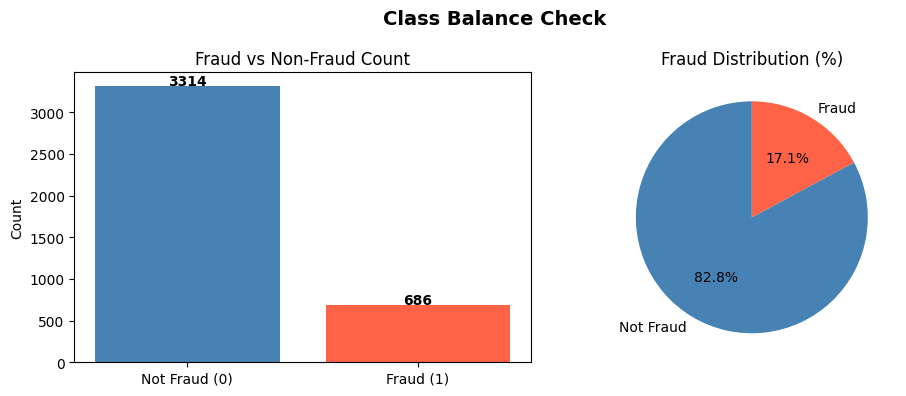

Fraud rate: 17.15%


In [21]:
# Plot 1- Fraud class balence

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Count plot
fraud_counts = df['target_fraud'].value_counts()
axes[0].bar(['Not Fraud (0)', 'Fraud (1)'],
            fraud_counts.values,
            color=['steelblue', 'tomato'])
axes[0].set_title('Fraud vs Non-Fraud Count')
axes[0].set_ylabel('Count')
for i, v in enumerate(fraud_counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(fraud_counts.values,
            labels=['Not Fraud', 'Fraud'],
            colors=['steelblue', 'tomato'],
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('Fraud Distribution (%)')

plt.suptitle('Class Balance Check', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(BASE + 'reports/figures/01_fraud_balance.png', dpi=150)
plt.show()
print(f"Fraud rate: {df['target_fraud'].mean()*100:.2f}%")

Representing the split of fraudulent and non-fraudulent customers in terms of a bar chart and pie chart.

The data is an imbalanced dataset (where fraud is less than 1 in 5 of all customers).

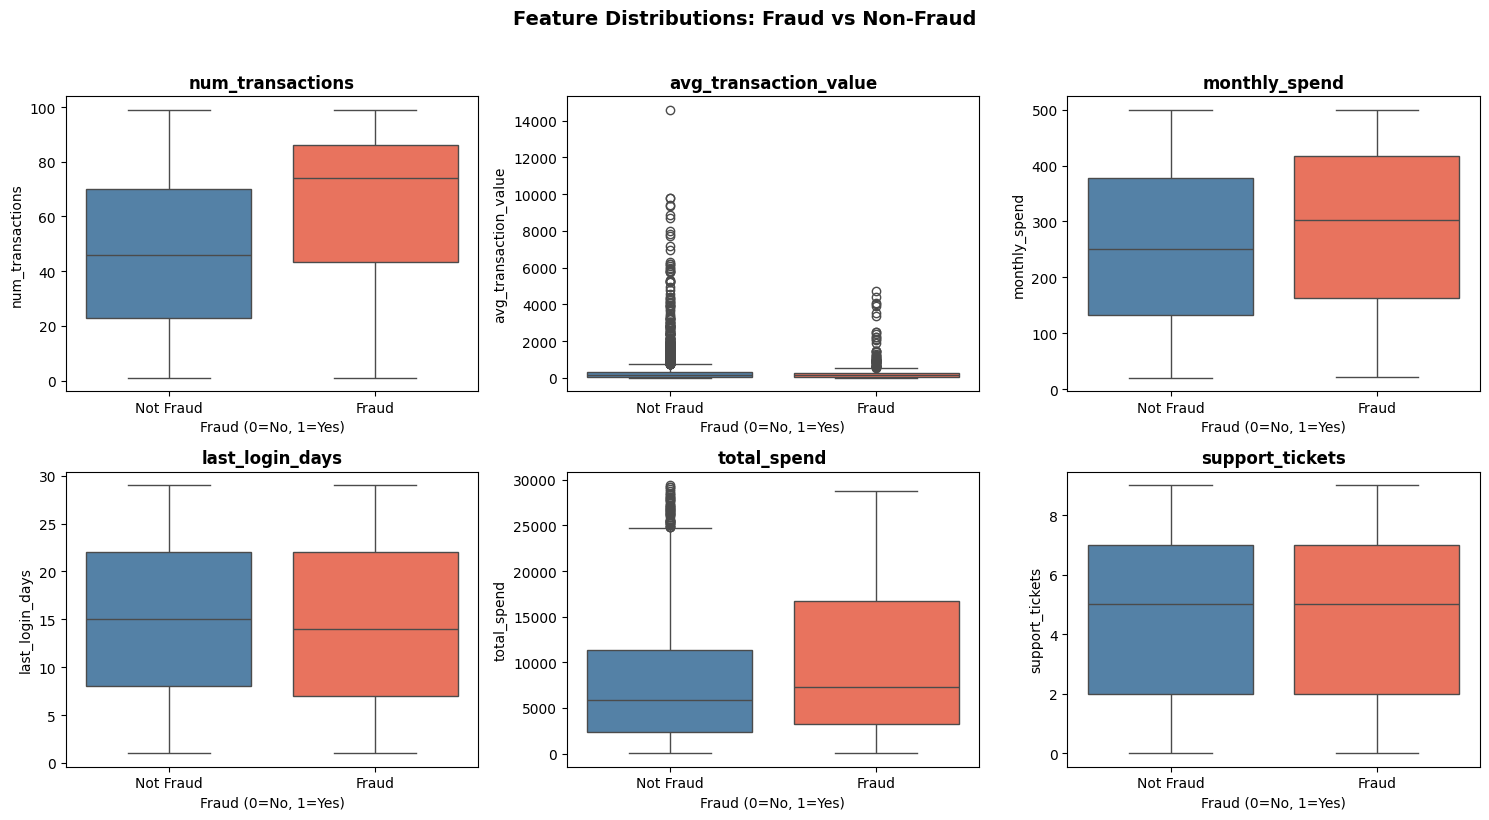

In [22]:
#Plot 2- Box plot (Not fraud and fraud)

features = [
    'num_transactions', 'avg_transaction_value',
    'monthly_spend', 'last_login_days',
    'total_spend', 'support_tickets'
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feat in enumerate(features):
    sns.boxplot(
        data=df,
        x='target_fraud',
        y=feat,
        hue='target_fraud',        # ← ADD THIS
        palette={0: 'steelblue', 1: 'tomato'},
        legend=False,              # ← ADD THIS (hides extra legend)
        ax=axes[i]
    )
    axes[i].set_title(f'{feat}', fontweight='bold')
    axes[i].set_xlabel('Fraud (0=No, 1=Yes)')
    axes[i].set_ylabel(feat)
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['Not Fraud', 'Fraud'])

plt.suptitle('Feature Distributions: Fraud vs Non-Fraud',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(BASE + 'reports/figures/02_boxplots_by_fraud.png',
            dpi=150, bbox_inches='tight')
plt.show()

- **num_transactions** — strongest signal. Fraud customers noticeably have more transactions approx. 75 compared to non-fraud approx.50.
- **monthly_spend** — slight difference. Fraud customers tend to spend a little more
- **total_spend** — slight difference. The total spend of fraud customers is higher than that of other customers.
- **avg_transaction_value** — weak signal. Both groups are similar with many outliers
This metric is the same for fraud and non-fraud groups.This metric is virtually the same for fraud and non-fraud.
There is no meaningful difference between both groups for support_tickets.


> The only distinctiveness between fraud and non-fraud is `num_transactions`. Most other features are redundant, which may restrict model performance.

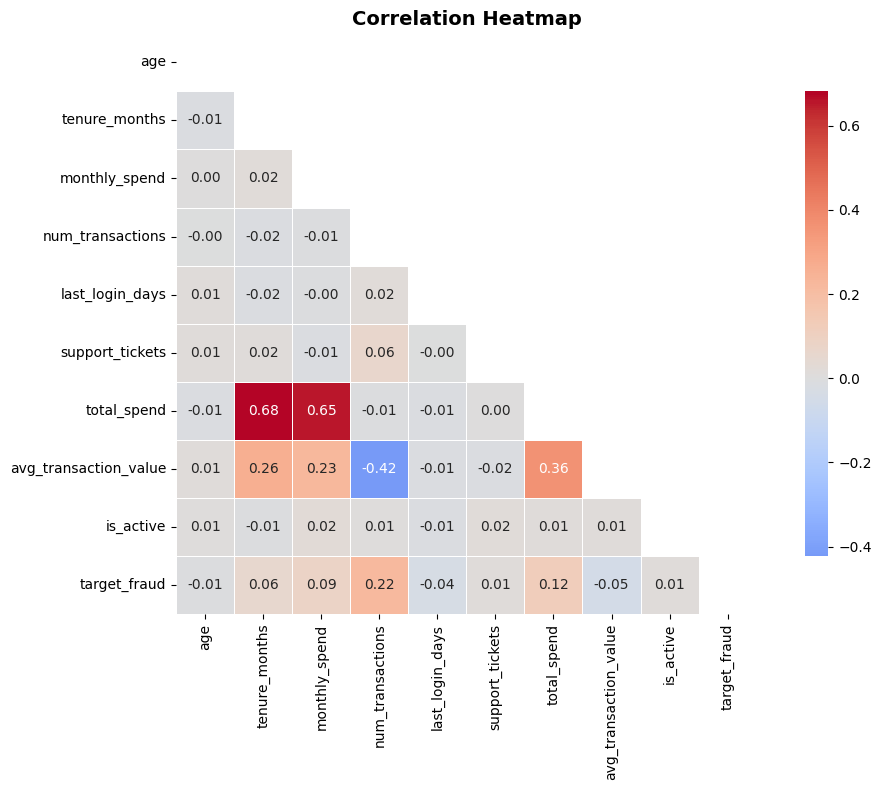

In [23]:
# Plot 3- Correlation heatmap

numerical_cols = [
    'age', 'tenure_months', 'monthly_spend', 'num_transactions',
    'last_login_days', 'support_tickets', 'total_spend',
    'avg_transaction_value', 'is_active', 'target_fraud']

corr = df[numerical_cols].corr()

plt.figure(figsize=(11, 8))
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True  # hide upper triangle

sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    square=True, linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(BASE + 'reports/figures/03_correlation_heatmap.png', dpi=150)
plt.show()

Indicates the strength of the correlation between each of the numerical features.
Values range from **-1** (opposite) to **+1** (identical). Numbers close to **0** indicate no relationship.

Key Findings:

There is a strong correlation between features:
The higher the tenure months, the more total spend.The relationship between tenure_months and total_spend is a positive one, as expected: longer customers spend more, overall.

1. `total_spend` & `monthly_spend`: **0.65** (more than 0.5) – higher monthly spend indicates higher total spend
The average value of a transaction.The number of transactions. (Decreased by -0.42 due to more transactions, less value per transaction.)

**Correlations with `target_fraud`:**
The number of transactions is a strong indicator of fraud, as indicated by the weakest signal with value of 0.22.
1. `total_spend` - **0.12** weak signal
2. `monthly_spend` - **0.09** very weak
3.  Everything else - near **0.00** no signal

 Key Takeaway:
> This is a clear indication of the feature dominance issue, as most of the features are very close to a zero correlation with fraud. Also, the variables total_spend, monthly_spend and tenure_months are heavily correlated to each other - that is, they contain redundant information.

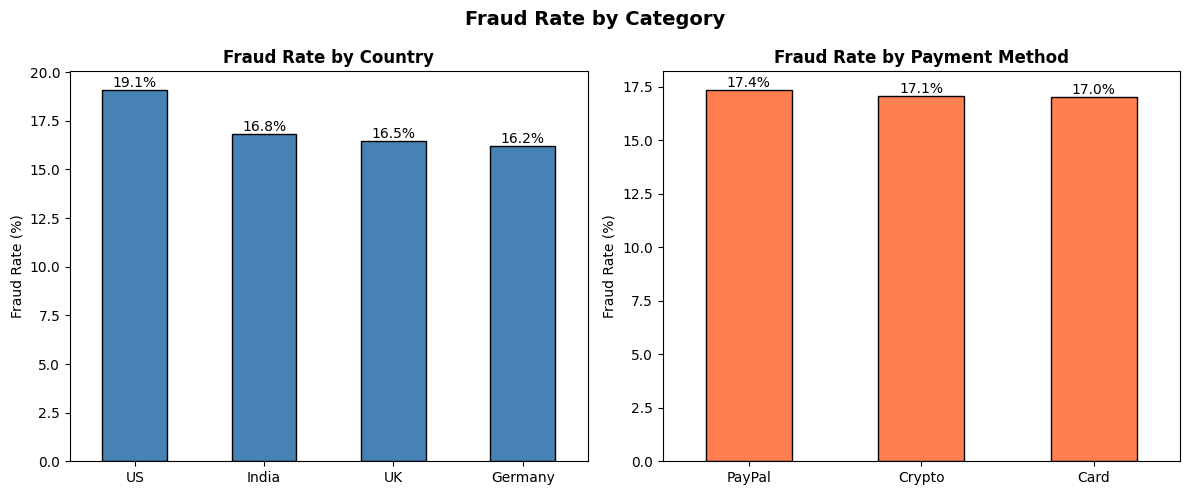

In [24]:
# Plot 4- Fraud rate by category
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# By country
country_fraud = df.groupby('country')['target_fraud'].mean() * 100
country_fraud.sort_values(ascending=False).plot(
    kind='bar', color='steelblue', ax=axes[0], edgecolor='black'
)
axes[0].set_title('Fraud Rate by Country', fontweight='bold')
axes[0].set_ylabel('Fraud Rate (%)')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=0)
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.1f}%',
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=10)

# By payment method
payment_fraud = df.groupby('payment_method')['target_fraud'].mean() * 100
payment_fraud.sort_values(ascending=False).plot(
    kind='bar', color='coral', ax=axes[1], edgecolor='black'
)
axes[1].set_title('Fraud Rate by Payment Method', fontweight='bold')
axes[1].set_ylabel('Fraud Rate (%)')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.1f}%',
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=10)

plt.suptitle('Fraud Rate by Category', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(BASE + 'reports/figures/04_fraud_by_category.png', dpi=150)
plt.show()

Fraud rates are almost the same in all countries and payment methods, so neither is a good predictor of fraud. This means that they are evidence of being weak features in the model.

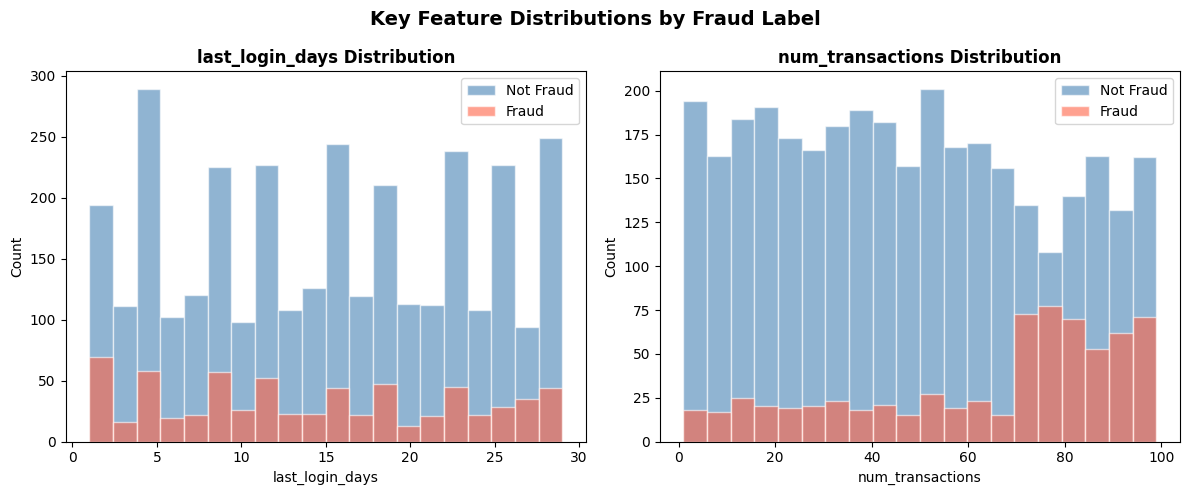

In [25]:
# Plot 5- Histogram- Last login days (Fraud vs not fraud)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Overlaid histogram
fraud = df[df['target_fraud'] == 1]['last_login_days']
no_fraud = df[df['target_fraud'] == 0]['last_login_days']

axes[0].hist(no_fraud, bins=20, alpha=0.6, color='steelblue',
             label='Not Fraud', edgecolor='white')
axes[0].hist(fraud, bins=20, alpha=0.6, color='tomato',
             label='Fraud', edgecolor='white')
axes[0].set_title('last_login_days Distribution', fontweight='bold')
axes[0].set_xlabel('last_login_days')
axes[0].set_ylabel('Count')
axes[0].legend()

# num_transactions histogram
fraud_txn = df[df['target_fraud'] == 1]['num_transactions']
no_fraud_txn = df[df['target_fraud'] == 0]['num_transactions']

axes[1].hist(no_fraud_txn, bins=20, alpha=0.6, color='steelblue',
             label='Not Fraud', edgecolor='white')
axes[1].hist(fraud_txn, bins=20, alpha=0.6, color='tomato',
             label='Fraud', edgecolor='white')
axes[1].set_title('num_transactions Distribution', fontweight='bold')
axes[1].set_xlabel('num_transactions')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.suptitle('Key Feature Distributions by Fraud Label',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(BASE + 'reports/figures/05_histograms.png', dpi=150)
plt.show()

**last_login_days:**
The distribution of the fraud and non-fraud customers are evenly distributed by all login day ranges
No pattern- Fraud happens without any regard for the times since they logged on.
- Weak fraud signal

**num_transactions:**
Clearly, the number of fraud cases (red, increased) is proportional to the number of transactions (80-100 range).
The bottom end of the transaction ranges is dominated by non-fraud.
- High level of fraud signal- lots of transactions being made, more likely to be fraudulent.

Key Takeaway:
> The key is that `num_transactions` is a clear separator of fraud vs non-fraud at higher values, which suggests that this variable is likely to be useful in developing the model. `last_login_days` has no discernable pattern and is not likely to assist the model.

## Previous rules for threshold

In [26]:
# Check thresholds before applying rules

print("KEY STATISTICS FOR RULE THRESHOLDS \n")

# Rule 1 threshold
p95_atv = df['avg_transaction_value'].quantile(0.95)
print(f"Rule 1 — 95th percentile of avg_transaction_value: {p95_atv:.2f}")

# Rule 2 preview
rule2 = (df['num_transactions'] < 5) & (df['monthly_spend'] > 500)
print(f"Rule 2 — num_transactions < 5 AND monthly_spend > 500: {rule2.sum()} customers")

# Rule 3 preview
rule3 = (df['support_tickets'] > 5) & (df['is_active'] == 0)
print(f"Rule 3 — support_tickets > 5 AND is_active == 0: {rule3.sum()} customers")

# Rule 4 preview
rule4 = (df['last_login_days'] > 20) & (df['num_transactions'] > 80)
print(f"Rule 4 — last_login_days > 20 AND num_transactions > 80: {rule4.sum()} customers")

KEY STATISTICS FOR RULE THRESHOLDS 

Rule 1 — 95th percentile of avg_transaction_value: 1247.82
Rule 2 — num_transactions < 5 AND monthly_spend > 500: 0 customers
Rule 3 — support_tickets > 5 AND is_active == 0: 769 customers
Rule 4 — last_login_days > 20 AND num_transactions > 80: 270 customers


## Updated rules

In [27]:
# Check thresholds before applying rules

print("KEY STATISTICS FOR RULE THRESHOLDS \n")

# Rule 1 threshold
rule1 = df['num_transactions'] > 70
print(f"Rule 1 — num_transactions > 70: {rule1.sum()} customers")

# Rule 2 preview
rule2 = (df['num_transactions'] > 50) & (df['monthly_spend'] < 100)
print(f"Rule 2 — num_transactions > 50 AND monthly_spend < 100: {rule2.sum()} customers")

# Rule 3 preview
rule3 = df['support_tickets'] > 7
print(f"Rule 3 — support_tickets > 7: {rule3.sum()} customers")

# Rule 4 preview
rule4 = (df['last_login_days'] > 20) & (df['num_transactions'] > 80)
print(f"Rule 4 — last_login_days > 20 AND num_transactions > 80: {rule4.sum()} customers")

KEY STATISTICS FOR RULE THRESHOLDS 

Rule 1 — num_transactions > 70: 1202 customers
Rule 2 — num_transactions > 50 AND monthly_spend < 100: 330 customers
Rule 3 — support_tickets > 7: 837 customers
Rule 4 — last_login_days > 20 AND num_transactions > 80: 270 customers


Rule Thresholds — Previous vs Updated

The rules were adjusted to identify more robust fraud indicators:
1. Rule 1 went from 200 to 1202
2. Rule 2 was corrected from 0 to 330
3. Rule 3 was raised slightly to 837
4. Rule 4 is unchanged at 270.

## Previous rules for suspicious code

In [28]:
# Apply rule based suspicious code

# Start with zero score for everyone
df['raw_score'] = 0

# Rule 1: Unusually high avg transaction value → +3
p95_atv = df['avg_transaction_value'].quantile(0.95)
df.loc[df['avg_transaction_value'] > p95_atv, 'raw_score'] += 3

# Rule 2: Very few transactions but high monthly spend → +2
df.loc[
    (df['num_transactions'] < 5) &
    (df['monthly_spend'] > 500),
    'raw_score'
] += 2

# Rule 3: Many support tickets AND inactive → +2
df.loc[
    (df['support_tickets'] > 5) &
    (df['is_active'] == 0),
    'raw_score'
] += 2

# Rule 4: Long login gap but burst of transactions → +3
df.loc[
    (df['last_login_days'] > 20) &
    (df['num_transactions'] > 80),
    'raw_score'
] += 3

# Cap at 10 then normalise to 0.0 - 1.0
df['raw_score']       = df['raw_score'].clip(upper=10)
df['suspicion_score'] = df['raw_score'] / 10

# Drop raw_score — we only keep suspicion_score
df.drop(columns=['raw_score'], inplace=True)

print(f"\nScore distribution:")
print(df['suspicion_score'].value_counts().sort_index())


Score distribution:
suspicion_score
0.0    2842
0.2     688
0.3     389
0.5      81
Name: count, dtype: int64


## Updated rules

In [29]:
# Apply rule based suspicion score

# Start with zero score for everyone
df['raw_score'] = 0

# Rule 1: High number of transactions → +3
df.loc[df['num_transactions'] > 70, 'raw_score'] += 3

# Rule 2: Many transactions but very low monthly spend → +2
df.loc[
    (df['num_transactions'] > 50) &
    (df['monthly_spend'] < 100),
    'raw_score'
] += 2

# Rule 3: Very high support tickets → +2
df.loc[
    df['support_tickets'] > 7,
    'raw_score'
] += 2

# Rule 4: Long login gap but burst of transactions → +3
df.loc[
    (df['last_login_days'] > 20) &
    (df['num_transactions'] > 80),
    'raw_score'
] += 3

# Cap at 10 then normalise to 0.0 - 1.0
df['raw_score']       = df['raw_score'].clip(upper=10)
df['suspicion_score'] = df['raw_score'] / 10

# Drop raw_score — we only keep suspicion_score
df.drop(columns=['raw_score'], inplace=True)

print(f"\nScore distribution:")
print(df['suspicion_score'].value_counts().sort_index())


Score distribution:
suspicion_score
0.0    2134
0.2     634
0.3     593
0.4      30
0.5     300
0.6     184
0.7      39
0.8      77
1.0       9
Name: count, dtype: int64


The maximum score was previously **0.5** and most of the customers (2842) scored **0.0**. The distribution has become more broadly distributed after changes to the rules, with fewer customers having a score of 0.0 (down to 2134), and more customers being flagged at higher risk levels with scores distributed across 9 levels all the way up to 1.0. This provides the model with a lot more data to analyze and make decisions with when it comes to detecting fraud.

In [30]:
test_df['raw_score'] = 0

# Rule 1: High number of transactions → +3
test_df.loc[test_df['num_transactions'] > 70, 'raw_score'] += 3

# Rule 2: Many transactions but very low monthly spend → +2
test_df.loc[
    (test_df['num_transactions'] > 50) &
    (test_df['monthly_spend'] < 100),
    'raw_score'
] += 2

# Rule 3: Very high support tickets → +2
test_df.loc[
    test_df['support_tickets'] > 7,
    'raw_score'
] += 2

# Rule 4: Long login gap but burst of transactions → +3
test_df.loc[
    (test_df['last_login_days'] > 20) &
    (test_df['num_transactions'] > 80),
    'raw_score'
] += 3

# Cap at 10 then normalise to 0.0 - 1.0
test_df['raw_score']       = test_df['raw_score'].clip(upper=10)
test_df['suspicion_score'] = test_df['raw_score'] / 10

# Drop raw_score — we only keep suspicion_score
test_df.drop(columns=['raw_score'], inplace=True)

print(f"\nScore distribution:")
print(test_df['suspicion_score'].value_counts().sort_index())


Score distribution:
suspicion_score
0.0    556
0.2    144
0.3    133
0.4     10
0.5     81
0.6     42
0.7     10
0.8     21
1.0      3
Name: count, dtype: int64


## Previous code-  customer flagged

In [31]:
# How many customers flagged by each rule
p95_atv = df['avg_transaction_value'].quantile(0.95)

rule_summary = pd.DataFrame({
    'Rule': [
        'Rule 1: avg_transaction_value > 95th percentile',
        'Rule 2: num_transactions < 5 AND monthly_spend > 500',
        'Rule 3: support_tickets > 5 AND is_active == 0',
        'Rule 4: last_login_days > 20 AND num_transactions > 80'
    ],
    'Customers Flagged': [
        (df['avg_transaction_value'] > p95_atv).sum(),
        ((df['num_transactions'] < 5) & (df['monthly_spend'] > 500)).sum(),
        ((df['support_tickets'] > 5) & (df['is_active'] == 0)).sum(),
        ((df['last_login_days'] > 20) & (df['num_transactions'] > 80)).sum()
    ],
    'Points': [3, 2, 2, 3]
})

# Fraud rate among flagged customers per rule
fraud_rates = [
    df[df['avg_transaction_value'] > p95_atv]['target_fraud'].mean() * 100,
    df[(df['num_transactions'] < 5) & (df['monthly_spend'] > 500)]['target_fraud'].mean() * 100,
    df[(df['support_tickets'] > 5) & (df['is_active'] == 0)]['target_fraud'].mean() * 100,
    df[(df['last_login_days'] > 20) & (df['num_transactions'] > 80)]['target_fraud'].mean() * 100
]

rule_summary['Fraud Rate Among Flagged %'] = [f"{r:.1f}%" for r in fraud_rates]

print("RULE FLAG SUMMARY")
display(rule_summary)

RULE FLAG SUMMARY


,Rule,Customers Flagged,Points,Fraud Rate Among Flagged %
0,Rule 1: avg_transaction_value > 95th percentile,200,3,10.5%
1,Rule 2: num_transactions < 5 AND monthly_spend...,0,2,nan%
2,Rule 3: support_tickets > 5 AND is_active == 0,769,2,17.9%
3,Rule 4: last_login_days > 20 AND num_transacti...,270,3,25.2%


## Updated code- Customer lagged

In [32]:
# How many customers flagged by each rule

rule_summary = pd.DataFrame({
    'Rule': [
        'Rule 1: num_transactions > 70',
        'Rule 2: num_transactions > 50 AND monthly_spend < 100',
        'Rule 3: support_tickets > 7',
        'Rule 4: last_login_days > 20 AND num_transactions > 80'
    ],
    'Customers Flagged': [
        (df['num_transactions'] > 70).sum(),
        ((df['num_transactions'] > 50) & (df['monthly_spend'] < 100)).sum(),
        (df['support_tickets'] > 7).sum(),
        ((df['last_login_days'] > 20) & (df['num_transactions'] > 80)).sum()
    ],
    'Points': [3, 2, 2, 3]
})

# Fraud rate among flagged customers per rule
fraud_rates = [
    df[df['num_transactions'] > 70]['target_fraud'].mean() * 100,
    df[(df['num_transactions'] > 50) & (df['monthly_spend'] < 100)]['target_fraud'].mean() * 100,
    df[df['support_tickets'] > 7]['target_fraud'].mean() * 100,
    df[(df['last_login_days'] > 20) & (df['num_transactions'] > 80)]['target_fraud'].mean() * 100
]

rule_summary['Fraud Rate Among Flagged %'] = [f"{r:.1f}%" for r in fraud_rates]

print("RULE FLAG SUMMARY")
display(rule_summary)

RULE FLAG SUMMARY


,Rule,Customers Flagged,Points,Fraud Rate Among Flagged %
0,Rule 1: num_transactions > 70,1202,3,33.4%
1,Rule 2: num_transactions > 50 AND monthly_spen...,330,2,19.1%
2,Rule 3: support_tickets > 7,837,2,16.0%
3,Rule 4: last_login_days > 20 AND num_transacti...,270,3,25.2%


The new rules are a significant improvement. Because the fraud rate has gone up dramatically in this rule, it is now the strongest rule with the number of customers that are flagged for fraud in this rule jumped from 200 to **1202 customers**. Before flagging, Rule 2 had a perfect 10, but is now correctly identifying 330 suspicious customers at a 19.1% fraud rate. Rule 3 flags a little more customers (769 to 837) and has a similar fraud rate. The second strongest rule, Rule 4, shows 270 customers and 25.2% fraud rate – no change.

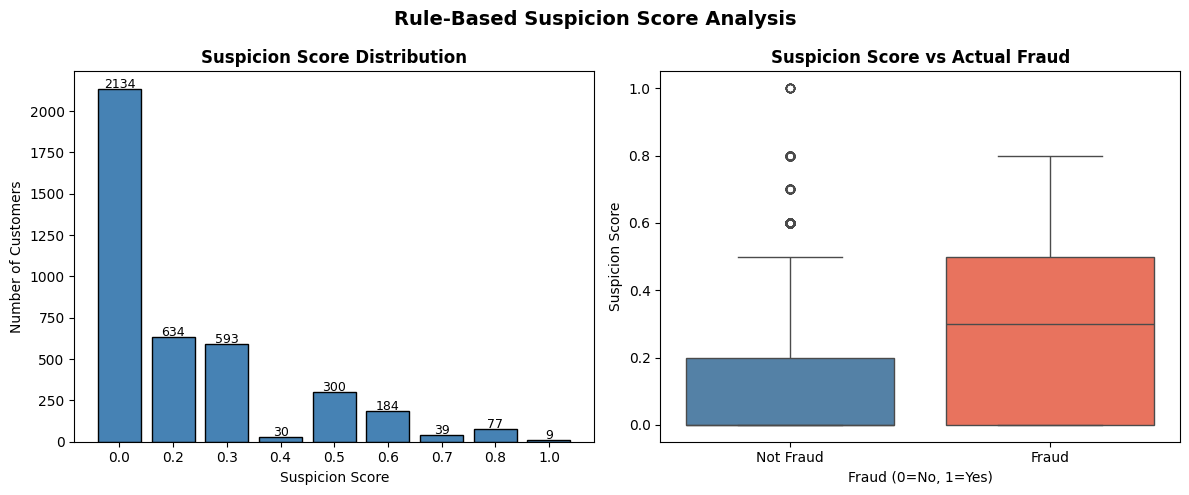

In [33]:
# Plots- Suspicion score distribution

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1 — Score distribution
score_counts = df['suspicion_score'].value_counts().sort_index()
axes[0].bar(
    score_counts.index.astype(str),
    score_counts.values,
    color='steelblue', edgecolor='black'
)
axes[0].set_title('Suspicion Score Distribution', fontweight='bold')
axes[0].set_xlabel('Suspicion Score')
axes[0].set_ylabel('Number of Customers')
for p, v in zip(score_counts.index.astype(str), score_counts.values):
    axes[0].text(p, v + 5, str(v), ha='center', fontsize=9)

# Plot 2 — Suspicion score vs actual fraud
sns.boxplot(
    data=df,
    x='target_fraud',
    y='suspicion_score',
    hue='target_fraud',
    palette={0: 'steelblue', 1: 'tomato'},
    legend=False,
    ax=axes[1]
)
axes[1].set_title('Suspicion Score vs Actual Fraud', fontweight='bold')
axes[1].set_xlabel('Fraud (0=No, 1=Yes)')
axes[1].set_ylabel('Suspicion Score')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Not Fraud', 'Fraud'])

plt.suptitle('Rule-Based Suspicion Score Analysis',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(BASE + 'reports/figures/06_suspicion_score.png',
            dpi=150, bbox_inches='tight')
plt.show()

The new rules give a much wider score distribution and there is a **very obvious separation** between the fraud and non-fraud customers on the boxplot.

There was a significant increase in scores, with the distribution of scores (left) having the majority still scoring at **0.0** (2134), but also the scores distributed across 9 levels up to **1.0**, with 300 customers scoring at 0.5 and 77 customers scoring at 0.8. More important, the box plot (right) now reveals that the suspicion scores of the fraud customers are significantly higher (median ~0.3) than the suspicion scores of the non-fraud customers (median ~0.1), which is exactly what the new rules are intended to achieve.

In [34]:
# Validate- does high score mean more fraud?

print("FRAUD RATE BY SUSPICION SCORE\n")

validation = df.groupby('suspicion_score')['target_fraud'].agg(
    Total='count',
    Fraud_Cases='sum'
)
validation['Fraud_Rate_%'] = (
    validation['Fraud_Cases'] / validation['Total'] * 100
).round(2)

display(validation)

print(f"\nOverall fraud rate:               {df['target_fraud'].mean()*100:.2f}%")
print(f"Fraud rate at suspicion_score=0:  {df[df['suspicion_score']==0.0]['target_fraud'].mean()*100:.2f}%")
print(f"Fraud rate at suspicion_score=0.3+: {df[df['suspicion_score']>=0.3]['target_fraud'].mean()*100:.2f}%")

FRAUD RATE BY SUSPICION SCORE



,Total,Fraud_Cases,Fraud_Rate_%
suspicion_score,,,
0.0,2134,224,10.50
0.2,634,57,8.99
0.3,593,226,38.11
0.4,30,4,13.33
0.5,300,99,33.00
0.6,184,51,27.72
0.7,39,8,20.51
0.8,77,17,22.08
1.0,9,0,0.00



Overall fraud rate:               17.15%
Fraud rate at suspicion_score=0:  10.50%
Fraud rate at suspicion_score=0.3+: 32.87%


The new regulation is substantially improved from the old one. The previous scores ranged between 16-19 percent fraud rate and there was minimal variation. Customers that score 0.0 have a score of 10.5% fraud- a fairly low risk score, while customers that score 0.3 or above reach 32.87%- almost double the average of 17.15%. The highest fraud rate is at score 0.3 at 38.11%, whereas the 0.5 score is 33.00% and the 0.6 is 27.72%, which shows that the new rules are working well to separate suspicious customers from normal customers. The only exception is score 1.0 with 0% fraud rate, but this is not reliable because only **9 customers** had a score of 1.0.

In [35]:
# Save data with suspicious code

df.to_csv(BASE + 'data/data_clean.csv', index=False)
test_df.to_csv(BASE + 'data/test_clean.csv', index=False)

print(" data_clean.csv updated with suspicion_score!")
print(f"Shape: {df.shape}")

# Verify
verify = pd.read_csv(BASE + 'data/data_clean.csv')
print(f"\n Verified — suspicion_score column exists: {'suspicion_score' in verify.columns}")
print(f"Missing values: {verify.isnull().sum().sum()}")
print(f"\nSample suspicion scores:\n{verify['suspicion_score'].head(10).values}")

 data_clean.csv updated with suspicion_score!
Shape: (4000, 17)

 Verified — suspicion_score column exists: True
Missing values: 0

Sample suspicion scores:
[0.  0.  0.  0.  0.3 0.  0.8 0.  0.  0. ]


In [36]:
# IQR Outlier Detection per country
# Using 90th percentile as upper bound since monthly_spend is capped at 500

def flag_iqr_outlier(group):
    upper_bound = group['monthly_spend'].quantile(0.90)
    group = group.copy()
    group['spend_outlier'] = (group['monthly_spend'] > upper_bound).astype(int)
    return group

df = df.groupby('country', group_keys=False).apply(flag_iqr_outlier)

print("90th PERCENTILE THRESHOLDS PER COUNTRY \n")
for country in df['country'].unique():
    subset = df[df['country'] == country]['monthly_spend']
    upper = subset.quantile(0.90)
    print(f"{country}: 90th Percentile Upper Bound = {upper:.2f}")

print(f"\n OUTLIERS FLAGGED PER COUNTRY")
print(df.groupby('country')['spend_outlier'].sum())
print(f"\nTotal outliers flagged: {df['spend_outlier'].sum()}")

90th PERCENTILE THRESHOLDS PER COUNTRY 

Germany: 90th Percentile Upper Bound = 461.13
US: 90th Percentile Upper Bound = 445.94
UK: 90th Percentile Upper Bound = 451.77
India: 90th Percentile Upper Bound = 452.21

 OUTLIERS FLAGGED PER COUNTRY
country
Germany     97
India       98
UK         107
US          99
Name: spend_outlier, dtype: int64

Total outliers flagged: 401


C:\Users\abina\AppData\Local\Temp\ipykernel_8068\1370987725.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('country', group_keys=False).apply(flag_iqr_outlier)


The outlier detection has been corrected after changing the method from IQR (flagged 0 customers) to the **90th percentile threshold**. The number of outliers are around 10% of the customers per country: Germany (97), US (99), UK (107), India (98) equals to 401. The column "spend_outlier" is now a useful feature for the model. The DeprecationWarning can be safely ignored as it does not affect the results.

In [37]:
# Are outliers more likely to be fraudulent?
# First check what values spend_outlier actually has

print("spend_outlier value counts")
print(df['spend_outlier'].value_counts())
print(f"dtype: {df['spend_outlier'].dtype}")
print()

# Make sure it's integer type
df['spend_outlier'] = df['spend_outlier'].astype(int)

# Group and aggregate
outlier_fraud = df.groupby('spend_outlier')['target_fraud'].agg(
    Total='count',
    Fraud_Cases='sum'
)

outlier_fraud['Fraud_Rate_%'] = (
    outlier_fraud['Fraud_Cases'] / outlier_fraud['Total'] * 100
).round(2)

# Safe index rename — only rename what actually exists
index_map = {0: 'Not Outlier', 1: 'Outlier'}
outlier_fraud.index = [index_map[i] for i in outlier_fraud.index]

print("FRAUD RATE: OUTLIERS vs NON-OUTLIERS")
display(outlier_fraud)

overall = df['target_fraud'].mean() * 100
print(f"\nOverall fraud rate:         {overall:.2f}%")
print(f"Fraud rate (outliers):      {df[df['spend_outlier']==1]['target_fraud'].mean()*100:.2f}%")
print(f"Fraud rate (non-outliers):  {df[df['spend_outlier']==0]['target_fraud'].mean()*100:.2f}%")

spend_outlier value counts
spend_outlier
0    3599
1     401
Name: count, dtype: int64
dtype: int64

FRAUD RATE: OUTLIERS vs NON-OUTLIERS


,Total,Fraud_Cases,Fraud_Rate_%
Not Outlier,3599,593,16.48
Outlier,401,93,23.19



Overall fraud rate:         17.15%
Fraud rate (outliers):      23.19%
Fraud rate (non-outliers):  16.48%


High spenders (top 10% of spenders per country) are then compared to non-outliers to determine whether they are more likely to engage in fraud.

The fraud rate of outlier customers is significantly higher than that of non-outliers at 23.19% compared to 16.48% overall. This indicates a lack of confidence in some of the spenders, which is a **useful feature** for the fraud detection model, as they are the ones that spend in an unusual way.

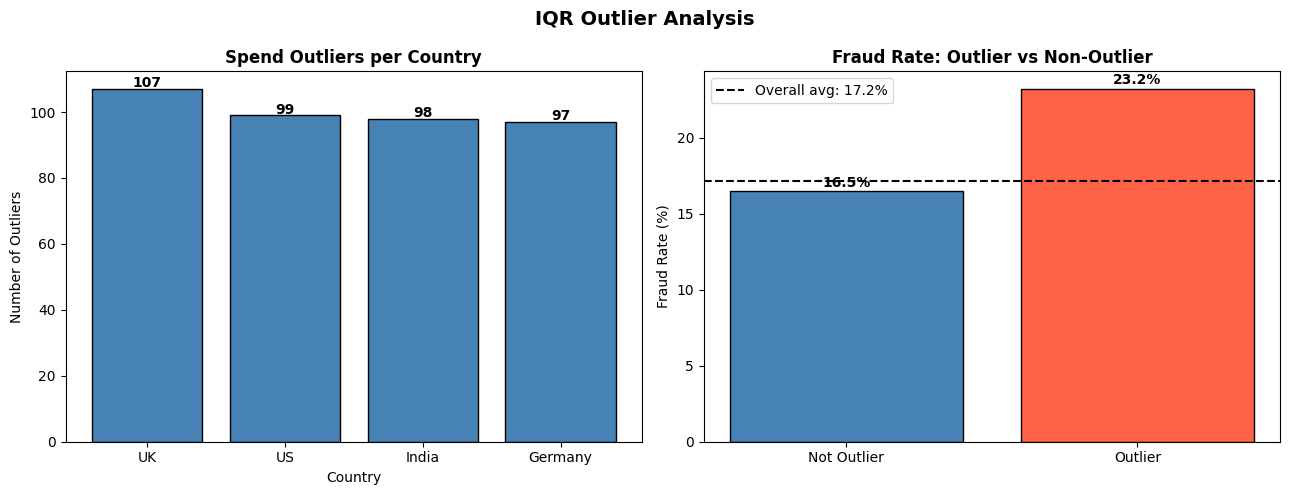

In [38]:
# plot 1- Outliers per country

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Outlier count per country
outlier_counts = df.groupby('country')['spend_outlier'].sum().sort_values(ascending=False)
axes[0].bar(
    outlier_counts.index,
    outlier_counts.values,
    color='steelblue', edgecolor='black'
)
axes[0].set_title('Spend Outliers per Country', fontweight='bold')
axes[0].set_xlabel('Country')
axes[0].set_ylabel('Number of Outliers')
for i, v in enumerate(outlier_counts.values):
    axes[0].text(i, v + 0.5, str(v), ha='center', fontweight='bold')

# Fraud rate: outlier vs non-outlier
fraud_rates = [
    df[df['spend_outlier']==0]['target_fraud'].mean() * 100,
    df[df['spend_outlier']==1]['target_fraud'].mean() * 100
]
bars = axes[1].bar(
    ['Not Outlier', 'Outlier'],
    fraud_rates,
    color=['steelblue', 'tomato'],
    edgecolor='black'
)
axes[1].set_title('Fraud Rate: Outlier vs Non-Outlier', fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Fraud Rate (%)')
axes[1].axhline(
    y=df['target_fraud'].mean()*100,
    color='black', linestyle='--',
    label=f'Overall avg: {df["target_fraud"].mean()*100:.1f}%'
)
axes[1].legend()
for bar, rate in zip(bars, fraud_rates):
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.3,
        f'{rate:.1f}%', ha='center', fontweight='bold'
    )

plt.suptitle('IQR Outlier Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(BASE + 'reports/figures/07_outlier_analysis.png',
            dpi=150, bbox_inches='tight')
plt.show()

The left chart shows spend outliers are evenly distributed across all countries — UK (107), US (99), India (98), and Germany (97)- confirming the 90th percentile threshold worked fairly per country.

The right chart clearly shows that **outlier customers have a 23.2% fraud rate**, well above the overall average of 17.2% and non-outliers at just 16.5%. This proves that unusually high spenders are genuinely more suspicious, making `spend_outlier` a valuable feature for the model.

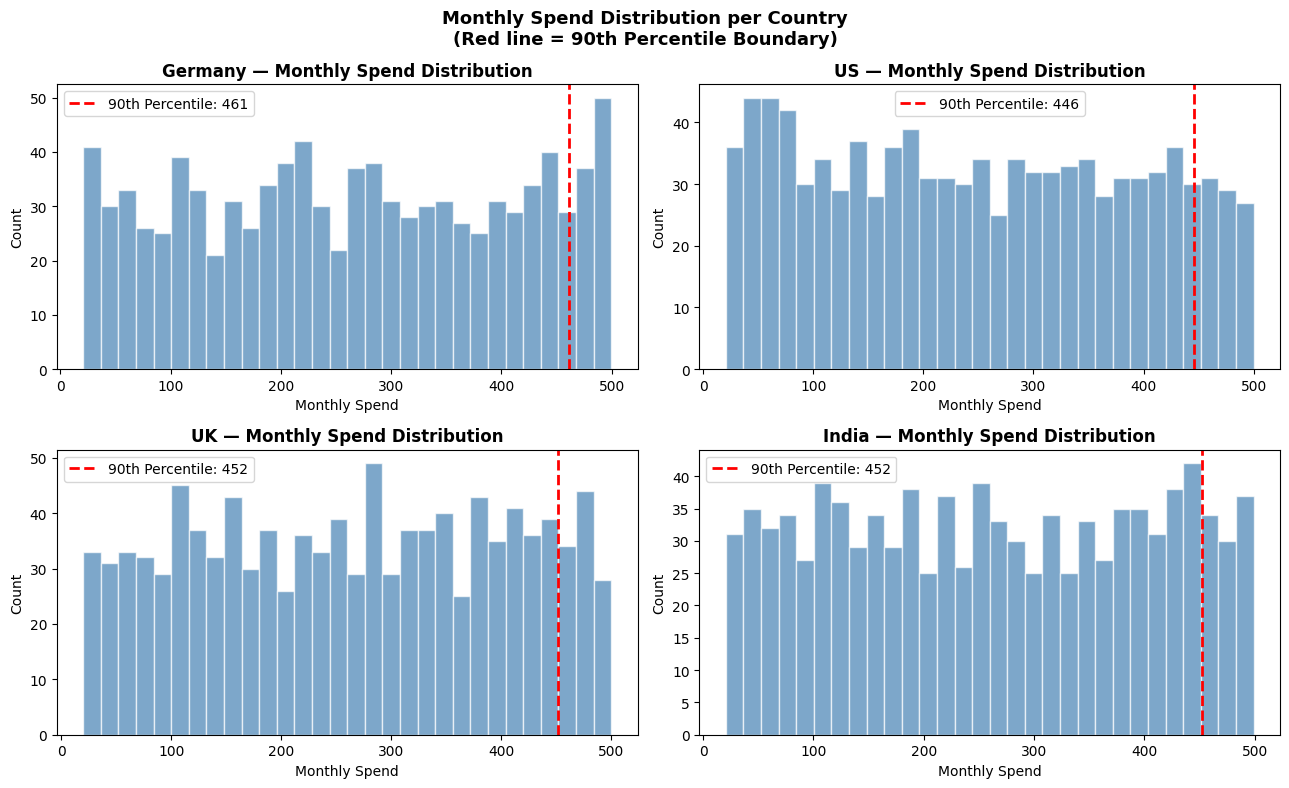

In [39]:
# Plot 2 — Monthly spend with outlier boundaries (90th percentile)

countries = df['country'].unique()
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.flatten()

for i, country in enumerate(countries):
    subset = df[df['country'] == country]
    upper = subset['monthly_spend'].quantile(0.90)  # updated to 90th percentile

    axes[i].hist(
        subset['monthly_spend'],
        bins=30, color='steelblue',
        edgecolor='white', alpha=0.7
    )
    axes[i].axvline(
        upper, color='red',
        linestyle='--', linewidth=2,
        label=f'90th Percentile: {upper:.0f}'  # updated label
    )
    axes[i].set_title(f'{country} — Monthly Spend Distribution',
                      fontweight='bold')
    axes[i].set_xlabel('Monthly Spend')
    axes[i].set_ylabel('Count')
    axes[i].legend()

plt.suptitle('Monthly Spend Distribution per Country\n(Red line = 90th Percentile Boundary)',  # updated title
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(BASE + 'reports/figures/08_spend_distribution_per_country.png',
            dpi=150, bbox_inches='tight')
plt.show()

The image displays two histograms, one for each country: monthly spend per customer in each country, red dashed line represents the 90th percentile boundary – flagged as outliers are customers spending more than this boundary.

As all 4 countries have a fairly uniform spread between £20 and £500, this is as expected the data was synthetic with a cap at 500 for the data to be taken. The 90th percentile boundary stays at a consistent level for all countries, at £446–£461, which indicates that any customers with spending above this level are deemed ‘high spenders' and are thus flagged as potentially suspicious.

In [40]:
# Full summary table

print(" COMPLETE OUTLIER SUMMARY \n")

summary_rows = []

for country in df['country'].unique():
    subset = df[df['country'] == country]
    outliers = subset[subset['spend_outlier'] == 1]
    non_outliers = subset[subset['spend_outlier'] == 0]

    summary_rows.append({
        'Country': country,
        'Total Customers': len(subset),
        'Outliers Flagged': len(outliers),
        'Outlier %': f"{len(outliers)/len(subset)*100:.1f}%",
        'Fraud Rate (Outliers) %': f"{outliers['target_fraud'].mean()*100:.1f}%" if len(outliers) > 0 else "N/A",
        'Fraud Rate (Non-Outliers) %': f"{non_outliers['target_fraud'].mean()*100:.1f}%"
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

 COMPLETE OUTLIER SUMMARY 



,Country,Total Customers,Outliers Flagged,Outlier %,Fraud Rate (Outliers) %,Fraud Rate (Non-Outliers) %
0,Germany,968,97,10.0%,21.6%,15.6%
1,US,990,99,10.0%,26.3%,18.3%
2,UK,1062,107,10.1%,23.4%,15.7%
3,India,980,98,10.0%,21.4%,16.3%


The cut-off point of 90th percentile is found to be consistent across all countries – in each country, 10% of customers are identified as high spenders. Outliers have a significantly higher fraud rate than non-outliers in all of the countries, with US outliers having the highest at 26.3% vs 18.3% for non-outliers, followed by UK (23.4% vs 15.7%), Germany (21.6% vs 15.6%) and India (21.4% vs 16.3%). This pattern in all four countries is considered a genuine usefulness of `spend_outlier` for detecting fraud.

In [41]:
# Handoff notes for Person 2

fraud_rate         = df['target_fraud'].mean() * 100
outlier_total      = df['spend_outlier'].sum()
outlier_fraud_rate = df[df['spend_outlier']==1]['target_fraud'].mean() * 100

handoff_notes = f"""
========================================================
 HANDOFF NOTES — PERSON 1 → PERSON 2
========================================================

 DATASET SUMMARY:
  - Train shape : {df.shape}
  - Total fraud cases : {df['target_fraud'].sum()} ({fraud_rate:.2f}%)
  - Class imbalance : YES — Person 3 must use class_weight or SMOTE

 KEY EDA FINDINGS:
  - Strongest fraud signals: num_transactions, total_spend, monthly_spend
  - Fraud customers tend to have HIGH num_transactions
  - No meaningful difference in fraud rate across countries or payment methods
  - Most features show weak correlation with fraud — feature dominance issue noted

 SUSPICION SCORE (UPDATED RULES):
  - Rule-based score (0.0 to 1.0) added as suspicion_score column
  - Rule 1: num_transactions > 70 → +3 points
  - Rule 2: num_transactions > 50 AND monthly_spend < 100 → +2 points
  - Rule 3: support_tickets > 7 → +2 points
  - Rule 4: last_login_days > 20 AND num_transactions > 80 → +3 points
  - Validation confirmed: score 0.3+ shows 32.87% fraud rate vs 17.15% overall

 OUTLIER DETECTION (UPDATED METHOD):
  - Switched from IQR to 90th percentile per country
  - Total outliers flagged: {outlier_total}
  - Fraud rate among outliers: {outlier_fraud_rate:.2f}%
  - Outliers consistently show higher fraud rate across all countries

 FEATURES TO ENGINEER (Person 2):
  1. spend_per_txn   = total_spend / (num_transactions + 1e-5)
  2. login_frequency = 1 / (last_login_days + 1)
  3. support_rate    = support_tickets / (tenure_months + 1)
  4. Peer deviation z-scores:
     - Group by country + payment_method
     - Compute z-score for monthly_spend, num_transactions, avg_transaction_value
     - Name them: z_spend, z_txn_count, z_avg_txn_value

 FILES SAVED TO DRIVE:
  - data/data_clean.csv         ← main file (use this)
  - reports/figures/            ← all EDA plots (8 PNG files)
  - handoff_person1.txt         ← this summary

========================================================
"""

print(handoff_notes)

# Save as text file to Drive
with open(BASE + 'handoff_person1.txt', 'w') as f:
    f.write(handoff_notes)

print("Handoff notes saved to Drive as handoff_person1.txt!")


 HANDOFF NOTES — PERSON 1 → PERSON 2

 DATASET SUMMARY:
  - Train shape : (4000, 18)
  - Total fraud cases : 686 (17.15%)
  - Class imbalance : YES — Person 3 must use class_weight or SMOTE

 KEY EDA FINDINGS:
  - Strongest fraud signals: num_transactions, total_spend, monthly_spend
  - Fraud customers tend to have HIGH num_transactions
  - No meaningful difference in fraud rate across countries or payment methods
  - Most features show weak correlation with fraud — feature dominance issue noted

 SUSPICION SCORE (UPDATED RULES):
  - Rule-based score (0.0 to 1.0) added as suspicion_score column
  - Rule 1: num_transactions > 70 → +3 points
  - Rule 2: num_transactions > 50 AND monthly_spend < 100 → +2 points
  - Rule 3: support_tickets > 7 → +2 points
  - Rule 4: last_login_days > 20 AND num_transactions > 80 → +3 points
  - Validation confirmed: score 0.3+ shows 32.87% fraud rate vs 17.15% overall

 OUTLIER DETECTION (UPDATED METHOD):
  - Switched from IQR to 90th percentile per coun

UnicodeEncodeError: 'charmap' codec can't encode character '\u2192' in position 86: character maps to <undefined>